# Hasse Search Space Estimation

## Setup

In [1]:
import json
import numpy as np
import os
from pprint import pprint
from statistics import mean, stdev
from typing import List, Dict

In [2]:
%pip install matplotlib
import matplotlib.pyplot as plt

You should consider upgrading via the '/Users/christophstein/Documents/jku/gospl/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Util functions

In [3]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

In [4]:
def load_json(path: str) -> Dict:
    with open(path, "r") as json_file:
        return json.load(json_file)

## Load Data

In [5]:
def load_experiments(results_dir: str = "results") -> List:
    experiments = []

    for file_name in os.listdir(results_dir):
        if not file_name.endswith(".json"):
            continue

        experiment = load_json(f"{results_dir}/{file_name}")
        experiments.append(experiment)

    return experiments

In [6]:
def filter_experiments(experiments: List, params: Dict={}, prefix=None) -> List:
    filtered_experiments = []

    for experiment in experiments:
        if prefix is not None and not experiment["meta"]["experiment_prefix"].startswith(prefix):
            continue

        all_params_match = True
        for key in params:
            if experiment["params"][key] != params[key]:
                all_params_match = False
                break

        if all_params_match:
            filtered_experiments.append(experiment)

    return filtered_experiments

In [7]:
def sort_experiments(experiments: List, key: str):
    experiments.sort(key=lambda experiment: experiment["params"][key])

In [8]:
def get_buffer_counts(experiments: List, sorted=True) -> List[int]:

    buffer_counts = []
    add_none = False 

    for experiment in experiments:

        if experiment["params"]["buffer_qubits"] is not None:
            buffer_counts.append(experiment["params"]["buffer_qubits"])
        else:
            add_none = True

    buffer_counts = list(set(buffer_counts))

    if sorted:
        buffer_counts.sort()

    if add_none:
        buffer_counts.append(None)

    return buffer_counts

In [9]:
def get_variable_counts(experiments: List, sorted=True) -> List[int]:
    variable_counts = []

    for experiment in experiments:
        variable_counts.append(experiment["params"]["variable_count"])

    variable_counts = list(set(variable_counts))

    if sorted:
        variable_counts.sort()

    return variable_counts

In [10]:
def get_probabilities(experiments: List, constraint_violations: int = 0) -> List[float]:
    probabilities = []

    for experiment in experiments:

        for result in experiment["results"]:
            if result["constraint_violations"] == constraint_violations:
                probabilities.append(result["mean_prob"])
                break 

    return probabilities

In [11]:
def get_solution_counts(experiments: List, constraint_violations: int = 0) -> List[float]:
    solution_counts = []

    for experiment in experiments:

        for result in experiment["results"]:
            if result["constraint_violations"] == constraint_violations:
                solution_counts.append(result["state_count"])
                break 

    return solution_counts

In [12]:
def get_gate_counts(experiments: List) -> List[float]:
    gate_counts = []

    for experiment in experiments:
        gate_counts.append(experiment["encoding"]["gates"])

    return gate_counts

In [13]:
def get_circuit_depths(experiments: List) -> List[float]:
    gate_counts = []

    for experiment in experiments:
        gate_counts.append(experiment["encoding"]["depth"])

    return gate_counts

In [14]:
def get_constraint_counts(experiments: List) -> List[float]:
    constraint_counts = []

    for experiment in experiments:
        constraint_counts.append(experiment["encoding"]["constraints"])

    return constraint_counts

In [15]:
def compute_sudoku_search_space_sizes(experiments: List) -> List[int]:
    search_space_sizes = []

    for experiment in experiments:
        search_space_sizes.append(experiment["params"]["variable_count"] ** 4)

    search_space_sizes = list(set(search_space_sizes))
    search_space_sizes.sort()
    return search_space_sizes


In [16]:
def compute_graph_coloring_search_space_sizes(experiments: List) -> List[int]:
    search_space_sizes = []

    for experiment in experiments:
        search_space_sizes.append(experiment["params"]["node_count"] ** experiment["params"]["color_count"])

    search_space_sizes = list(set(search_space_sizes))
    search_space_sizes.sort()
    return search_space_sizes


## Visualization Functions

In [17]:
def plot_probability_per_buffer_count(experiments: List, target_path: None, classical_probability: None):
    buffer_counts = get_buffer_counts(experiments)

    x = []
    mean_probabilities = []
    std_probabilities = []

    for buffer_count in buffer_counts:
        rel_experiments = filter_experiments(experiments, params={
            "buffer_qubits": buffer_count
        })

        if buffer_count is None:
            # Depending on how the problem instance is initialized,
            # constraint counts and therefore buffer qubit counts
            # might deviate slightly.
            x.append(max(get_constraint_counts(rel_experiments)))
        else:
            x.append(buffer_count)

        solution_counts = get_solution_counts(rel_experiments, constraint_violations=0)
        probabilities = get_probabilities(
            rel_experiments, constraint_violations=0)
        
        probabilities = [
            probability * solution_count for probability, solution_count in zip(probabilities, solution_counts)
        ]

        mean_probabilities.append(mean(probabilities))
        std_probabilities.append(stdev(probabilities))

    ax = plt.subplot()

    ax.plot(x, mean_probabilities, label="QC probability") # TODO: Find better labels.

    lower_bounds = [value - std for value,
                    std in zip(mean_probabilities, std_probabilities)]
    upper_bounds = [value + std for value,
                    std in zip(mean_probabilities, std_probabilities)]

    ax.fill_between(
        x, lower_bounds, upper_bounds, alpha=0.2
    )

    if classical_probability is not None:
        classical_probability = max(get_solution_counts(experiments, constraint_violations=0)) * classical_probability
        ax.plot(x, [classical_probability for _ in x], label="classical probability", linestyle="dashed", linewidth=1)

    ax.set_xlabel("buffer qubits")
    ax.set_ylabel("probability")
    ax.set_xticks(x)

    ax.set_ylim(0)

    print("Probabilities:", mean_probabilities)
    print("Buffer counts:", x)

    plt.grid()
    plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [18]:
def plot_gate_count_per_buffer_count(experiments: List, target_path: None):
    buffer_counts = get_buffer_counts(experiments)

    x = []
    mean_gate_count = []
    std_gate_count = []

    for buffer_count in buffer_counts:
        rel_experiments = filter_experiments(experiments, params={
            "buffer_qubits": buffer_count
        })

        if buffer_count is None:
            # Depending on how the problem instance is initialized,
            # constraint counts and therefore buffer qubit counts
            # might deviate slightly.
            x.append(max(get_constraint_counts(rel_experiments)))
        else:
            x.append(buffer_count)

        gate_counts = get_gate_counts(rel_experiments)

        mean_gate_count.append(mean(gate_counts))
        std_gate_count.append(stdev(gate_counts))

    ax = plt.subplot()

    ax.plot(x, mean_gate_count)

    lower_bounds = [value - std for value, std in zip(mean_gate_count, std_gate_count)]
    upper_bounds = [value + std for value, std in zip(mean_gate_count, std_gate_count)]
    
    ax.fill_between(
        x, lower_bounds, upper_bounds, alpha=0.2
    )

    ax.set_xlabel("buffer qubits")
    ax.set_ylabel("gate count")
    ax.set_xticks(x)

    ax.set_ylim(0)

    print("Gate counts:", mean_gate_count)
    print("Buffer counts:", x)

    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [19]:
def plot_circuit_depth_per_buffer_count(experiments: List, target_path: None):
    buffer_counts = get_buffer_counts(experiments)

    x = []
    mean_circuit_depths = []
    std_circuit_depths = []

    for buffer_count in buffer_counts:
        rel_experiments = filter_experiments(experiments, params={
            "buffer_qubits": buffer_count
        })

        if buffer_count is None:
            # Depending on how the problem instance is initialized,
            # constraint counts and therefore buffer qubit counts
            # might deviate slightly.
            x.append(max(get_constraint_counts(rel_experiments)))
        else:
            x.append(buffer_count)

        circuit_depths = get_circuit_depths(rel_experiments)

        mean_circuit_depths.append(mean(circuit_depths))
        std_circuit_depths.append(stdev(circuit_depths))

    ax = plt.subplot()

    ax.plot(x, mean_circuit_depths)

    lower_bounds = [value - std for value, std in zip(mean_circuit_depths, std_circuit_depths)]
    upper_bounds = [value + std for value, std in zip(mean_circuit_depths, std_circuit_depths)]
    
    ax.fill_between(
        x, lower_bounds, upper_bounds, alpha=0.2
    )

    ax.set_xlabel("buffer qubits")
    ax.set_ylabel("circuit depth")
    ax.set_xticks(x)

    ax.set_ylim(0)

    print("Circuit depths:", mean_circuit_depths)
    print("Buffer counts:", x)

    plt.grid()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

## Data Analysis

In [20]:
experiments = load_experiments()

sudoku_experiments = filter_experiments(experiments, prefix="sudoku")
graph_coloring_experiments = filter_experiments(experiments, prefix="graph_coloring")

print(f"Number of sudoku experiments: {len(sudoku_experiments)}")
print(f"Search space sizes: {compute_sudoku_search_space_sizes(sudoku_experiments)}")

print(f"\nNumber of graph coloring experiments: {len(graph_coloring_experiments)}")
print(f"Search space sizes: {compute_graph_coloring_search_space_sizes(graph_coloring_experiments)}")

Number of sudoku experiments: 139
Search space sizes: [16, 256, 625]

Number of graph coloring experiments: 0
Search space sizes: []



Sudoku results with 2 unspecified cells

Probability of measuring a correct solution over buffer count:
Probabilities: [0.119799, 0.233261, 0.226362, 0.47285]
Buffer counts: [1, 3, 5, 7]


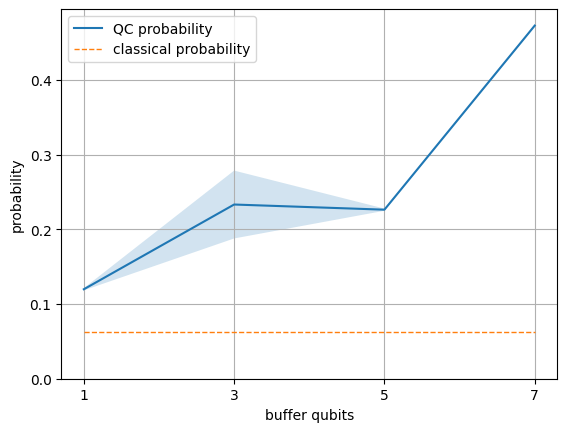

Circuit depth over buffer count:
Circuit depths: [46.3, 42.8, 38.6, 37.5]
Buffer counts: [1, 3, 5, 7]


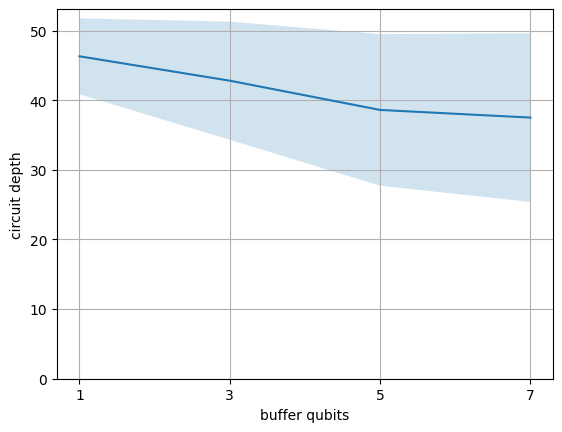


Sudoku results with 4 unspecified cells

Probability of measuring a correct solution over buffer count:
Probabilities: [0.008021, 0.018176, 0.02179888888888889, 0.01857, 0.03492]
Buffer counts: [1, 3, 5, 10, 17]


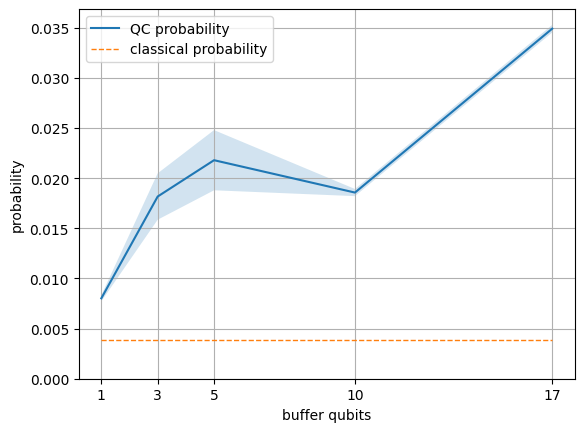

Circuit depth over buffer count:
Circuit depths: [97.1, 80.5, 76.2, 70.8, 68.6]
Buffer counts: [1, 3, 5, 10, 17]


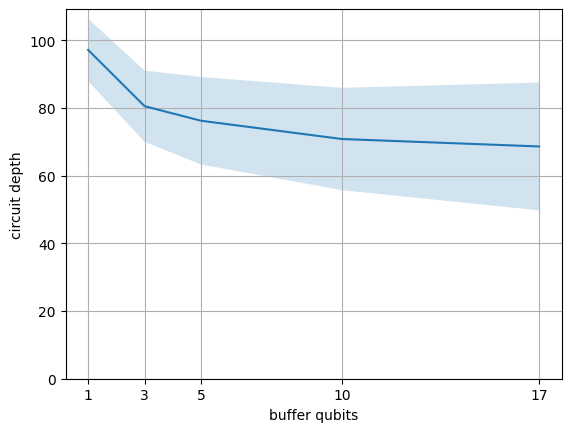


Sudoku results with 5 unspecified cells

Probability of measuring a correct solution over buffer count:
Probabilities: [0.001951, 0.004953, 0.0058519999999999996, 0.007206, 0.00878]
Buffer counts: [1, 3, 5, 10, 20]


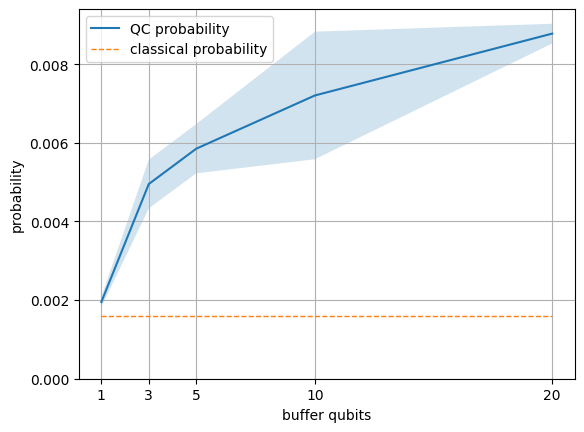

Circuit depth over buffer count:
Circuit depths: [127.8, 102.5, 94.9, 89.8, 86.33333333333333]
Buffer counts: [1, 3, 5, 10, 20]


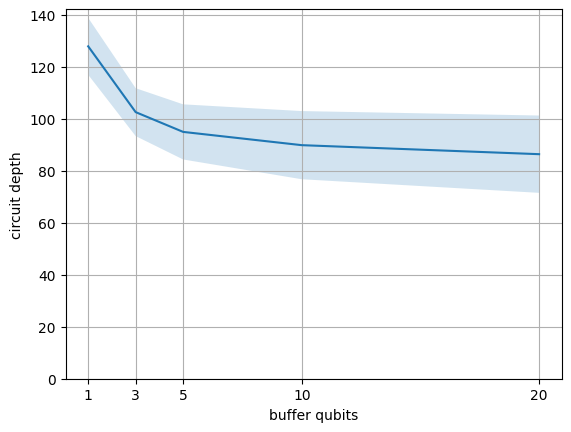

<Figure size 640x480 with 0 Axes>

In [21]:
variable_counts = get_variable_counts(sudoku_experiments)

for variable_count in variable_counts:
    rel_sudoku_experiments = filter_experiments(
        sudoku_experiments, params={
            "variable_count": variable_count
        }
    )

    printb(f"\nSudoku results with {variable_count} unspecified cells\n")

    print("Probability of measuring a correct solution over buffer count:")
    classical_probability = 1 / compute_sudoku_search_space_sizes(rel_sudoku_experiments)[0]
    plot_probability_per_buffer_count(
        rel_sudoku_experiments, target_path=f"results/figures/sudoku_{variable_count}v_probabilities.png", 
        classical_probability=classical_probability
    )

    print("Circuit depth over buffer count:")
    plot_circuit_depth_per_buffer_count(
        rel_sudoku_experiments, target_path=f"results/figures/sudoku_{variable_count}v_circuit_depths.png"
    )

    # print("Gate count over buffer count:")
    # plot_gate_count_per_buffer_count(
    #     rel_sudoku_experiments, target_path=f"results/figures/sudoku_{variable_count}v_gate_counts.png"
    # )